<a href="https://colab.research.google.com/github/PranavShirke/reloop/blob/main/DL_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "⚠️ No GPU detected! Training will be slow.")

# Install required packages
get_ipython().system('pip install -q ultralytics pycocotools Pillow tqdm')

print("✅ Dependencies installed!")


Wed Apr 22 01:25:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
import json
import shutil
from pathlib import Path

# Clone TACO repository (contains annotations + download script)
if not os.path.exists("TACO"):
    get_ipython().system('git clone https://github.com/pedropro/TACO.git')
    print("✅ TACO repository cloned!")
else:
    print("ℹ️ TACO already exists, skipping clone.")

# Install TACO dependencies
get_ipython().system('pip install -q -r TACO/requirements.txt')

# Download images from Flickr (this takes ~10-15 minutes)
os.chdir("TACO")
print("📥 Downloading TACO images from Flickr... This takes ~10-15 minutes.")
get_ipython().system('python download.py')
os.chdir("..")

# Verify download
annotations_path = "TACO/data/annotations.json"
if os.path.exists(annotations_path):
    with open(annotations_path) as f:
        data = json.load(f)
    print(f"✅ TACO loaded: {len(data['images'])} images, {len(data['annotations'])} annotations, {len(data['categories'])} categories")
else:
    raise FileNotFoundError("❌ annotations.json not found! Download may have failed.")



Cloning into 'TACO'...
remote: Enumerating objects: 740, done.
remote: Counting objects: 100% (435/435), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 740 (delta 416), reused 380 (delta 380), pack-reused 305 (from 1)
Receiving objects: 100% (740/740), 97.48 MiB | 28.69 MiB/s, done.
Resolving deltas: 100% (499/499), done.
✅ TACO repository cloned!
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 89.0 MB/s eta 0:00:00
📥 Downloading TACO images from Flickr... This takes ~10-15 minutes.
Note. If for any reason the connection is broken. Just call me again and I will start where I left.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/urllib3/response.py", line 779, in _error_catcher
    yield
  Fi

In [ ]:
import json

with open("TACO/data/annotations.json") as f:
    data = json.load(f)

print("=" * 60)
print("TACO DATASET CATEGORIES")
print("=" * 60)

# Count annotations per category
from collections import Counter
cat_counts = Counter()
for ann in data['annotations']:
    cat_counts[ann['category_id']] += 1

cat_id_to_name = {c['id']: c['name'] for c in data['categories']}

for cat_id, count in sorted(cat_counts.items(), key=lambda x: -x[1]):
    name = cat_id_to_name.get(cat_id, f"Unknown-{cat_id}")
    print(f"  [{cat_id:3d}] {name:35s} → {count:4d} annotations")

print(f"\nTotal annotations: {sum(cat_counts.values())}")

TACO DATASET CATEGORIES
  [ 59] Cigarette                           →  667 annotations
  [ 58] Unlabeled litter                    →  517 annotations
  [ 36] Plastic film                        →  451 annotations
  [  5] Clear plastic bottle                →  285 annotations
  [ 29] Other plastic                       →  273 annotations
  [ 39] Other plastic wrapper               →  260 annotations
  [ 12] Drink can                           →  229 annotations
  [  7] Plastic bottle cap                  →  209 annotations
  [ 55] Plastic straw                       →  157 annotations
  [  9] Broken glass                        →  138 annotations
  [ 57] Styrofoam piece                     →  112 annotations
  [  6] Glass bottle                        →  104 annotations
  [ 21] Disposable plastic cup              →  104 annotations
  [ 50] Pop tab                             →   99 annotations
  [ 14] Other carton                        →   93 annotations
  [ 33] Normal paper           

In [ ]:
import json
import os
import shutil
import random
from pathlib import Path
from tqdm import tqdm

# ─── OUR 15 WASTE CATEGORIES ───
CLASS_NAMES = [
    "Plastic Bottle",       # 0
    "Plastic Bag",          # 1
    "Plastic Wrapper",      # 2
    "Plastic Container",    # 3
    "Styrofoam",            # 4
    "Crisp MLP Packet",     # 5  (Multi-Layer Plastic)
    "Glass Bottle",         # 6
    "Broken Glass",         # 7
    "Aluminium Can",        # 8
    "Food Can",             # 9
    "Metal Scrap",          # 10
    "Cardboard",            # 11
    "Paper",                # 12
    "Cigarette",            # 13
    "Hazardous",            # 14
]

# ─── MAP TACO CATEGORY NAMES → OUR 15 CLASS IDs ───
# Keys are lowercase TACO category names → values are our class IDs
TACO_TO_RELOOP = {
    # 0: Plastic Bottle
    "clear plastic bottle": 0,
    "other plastic bottle": 0,

    # 1: Plastic Bag
    "single-use carrier bag": 1,
    "garbage bag": 1,
    "polypropylene bag": 1,
    "plastified paper bag": 1,
    "plastic bag - Loss": 1,

    # 2: Plastic Wrapper
    "other plastic wrapper": 2,
    "plastic film": 2,
    "six pack rings": 2,

    # 3: Plastic Container
    "disposable plastic cup": 3,
    "other plastic cup": 3,
    "other plastic container": 3,
    "spread tub": 3,
    "plastic utensils": 3,
    "plastic lid": 3,
    "plastic bottle cap": 3,
    "plastic straw": 3,
    "plastic gloves": 3,
    "other plastic": 3,
    "foam food container": 3,

    # 4: Styrofoam
    "styrofoam piece": 4,
    "foam cup": 4,

    # 5: Crisp/MLP Packet
    "crisp packet": 5,
    "aluminium blister pack": 5,
    "carded blister pack": 5,
    "squeezable tube": 5,

    # 6: Glass Bottle
    "glass bottle": 6,
    "glass jar": 6,
    "glass cup": 6,

    # 7: Broken Glass
    "broken glass": 7,

    # 8: Aluminium Can
    "drink can": 8,
    "pop tab": 8,

    # 9: Food Can
    "food can": 9,
    "aerosol": 9,

    # 10: Metal Scrap
    "aluminium foil": 10,
    "metal bottle cap": 10,
    "metal lid": 10,
    "scrap metal": 10,

    # 11: Cardboard
    "corrugated carton": 11,
    "pizza box": 11,
    "egg carton": 11,
    "meal carton": 11,
    "other carton": 11,
    "drink carton": 11,

    # 12: Paper
    "normal paper": 12,
    "magazine paper": 12,
    "wrapping paper": 12,
    "paper bag": 12,
    "tissues": 12,
    "toilet tube": 12,
    "paper cup": 12,
    "paper straw": 12,

    # 13: Cigarette
    "cigarette": 13,

    # 14: Hazardous
    "battery": 14,
}

# ─── LOAD ANNOTATIONS ───
with open("TACO/data/annotations.json") as f:
    coco = json.load(f)

cat_id_to_name = {c['id']: c['name'] for c in coco['categories']}
img_id_to_info = {img['id']: img for img in coco['images']}

# ─── BUILD PER-IMAGE ANNOTATION LISTS ───
img_annotations = {}
skipped_categories = set()
mapped_count = 0
skipped_count = 0

for ann in coco['annotations']:
    img_id = ann['image_id']
    cat_name = cat_id_to_name.get(ann['category_id'], "")
    cat_name_lower = cat_name.lower().strip()

    # Look up our class ID
    reloop_id = TACO_TO_RELOOP.get(cat_name_lower)
    if reloop_id is None:
        skipped_categories.add(cat_name)
        skipped_count += 1
        continue

    img_info = img_id_to_info.get(img_id)
    if img_info is None:
        continue

    img_w = img_info['width']
    img_h = img_info['height']

    # Convert COCO bbox [x_min, y_min, width, height] → YOLO [x_center, y_center, w, h] (normalized)
    bx, by, bw, bh = ann['bbox']
    x_center = (bx + bw / 2.0) / img_w
    y_center = (by + bh / 2.0) / img_h
    w_norm = bw / img_w
    h_norm = bh / img_h

    # Clamp to [0, 1]
    x_center = max(0.0, min(1.0, x_center))
    y_center = max(0.0, min(1.0, y_center))
    w_norm = max(0.001, min(1.0, w_norm))
    h_norm = max(0.001, min(1.0, h_norm))

    if img_id not in img_annotations:
        img_annotations[img_id] = []

    img_annotations[img_id].append(f"{reloop_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}")
    mapped_count += 1

print(f"✅ Mapped {mapped_count} annotations across {len(img_annotations)} images")
print(f"⚠️ Skipped {skipped_count} annotations from unmapped categories: {skipped_categories}")

# ─── CREATE YOLO DIRECTORY STRUCTURE ───
dataset_dir = Path("taco_yolo")
for split in ["train", "val"]:
    (dataset_dir / "images" / split).mkdir(parents=True, exist_ok=True)
    (dataset_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

# ─── SPLIT AND COPY FILES ───
image_ids = list(img_annotations.keys())
random.seed(42)
random.shuffle(image_ids)

split_idx = int(len(image_ids) * 0.85)  # 85% train, 15% val
train_ids = set(image_ids[:split_idx])
val_ids = set(image_ids[split_idx:])

copied = {"train": 0, "val": 0}
missing = 0

for img_id, labels in tqdm(img_annotations.items(), desc="Processing images"):
    img_info = img_id_to_info[img_id]
    img_filename = img_info['file_name']  # e.g., "batch_1/000001.jpg"

    # Find the actual image file
    src_path = Path("TACO/data") / img_filename
    if not src_path.exists():
        missing += 1
        continue

    split = "train" if img_id in train_ids else "val"
    safe_name = img_filename.replace("/", "_").replace("\\", "_")

    # Copy image
    dst_img = dataset_dir / "images" / split / safe_name
    shutil.copy2(src_path, dst_img)

    # Write YOLO label file
    label_name = Path(safe_name).stem + ".txt"
    dst_label = dataset_dir / "labels" / split / label_name
    with open(dst_label, "w") as f:
        f.write("\n".join(labels))

    copied[split] += 1

print(f"\n{'=' * 50}")
print(f"📊 DATASET READY:")
print(f"   Train: {copied['train']} images")
print(f"   Val:   {copied['val']} images")
print(f"   Missing images (failed download): {missing}")
print(f"   Classes: {len(CLASS_NAMES)}")
print(f"{'=' * 50}")

✅ Mapped 4177 annotations across 1449 images
⚠️ Skipped 607 annotations from unmapped categories: {'Unlabeled litter', 'Rope & strings', 'Shoe', 'Food waste', 'Disposable food container', 'Plastic glooves', 'Tupperware'}


Processing images: 100%|██████████| 1449/1449 [00:15<00:00, 91.51it/s]


📊 DATASET READY:
   Train: 1231 images
   Val:   218 images
   Missing images (failed download): 0
   Classes: 15


In [ ]:
import yaml
from pathlib import Path

dataset_config = {
    'path': str(Path("taco_yolo").resolve()),
    'train': 'images/train',
    'val': 'images/val',
    'nc': 15,
    'names': {
        0: 'Plastic Bottle',
        1: 'Plastic Bag',
        2: 'Plastic Wrapper',
        3: 'Plastic Container',
        4: 'Styrofoam',
        5: 'Crisp MLP Packet',
        6: 'Glass Bottle',
        7: 'Broken Glass',
        8: 'Aluminium Can',
        9: 'Food Can',
        10: 'Metal Scrap',
        11: 'Cardboard',
        12: 'Paper',
        13: 'Cigarette',
        14: 'Hazardous',
    }
}

yaml_path = "taco_yolo/taco.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False, sort_keys=False)

print(f"✅ Dataset config written to: {yaml_path}")
print(f"\nContents:")
with open(yaml_path) as f:
    print(f.read())


✅ Dataset config written to: taco_yolo/taco.yaml

Contents:
path: /content/taco_yolo
train: images/train
val: images/val
nc: 15
names:
  0: Plastic Bottle
  1: Plastic Bag
  2: Plastic Wrapper
  3: Plastic Container
  4: Styrofoam
  5: Crisp MLP Packet
  6: Glass Bottle
  7: Broken Glass
  8: Aluminium Can
  9: Food Can
  10: Metal Scrap
  11: Cardboard
  12: Paper
  13: Cigarette
  14: Hazardous



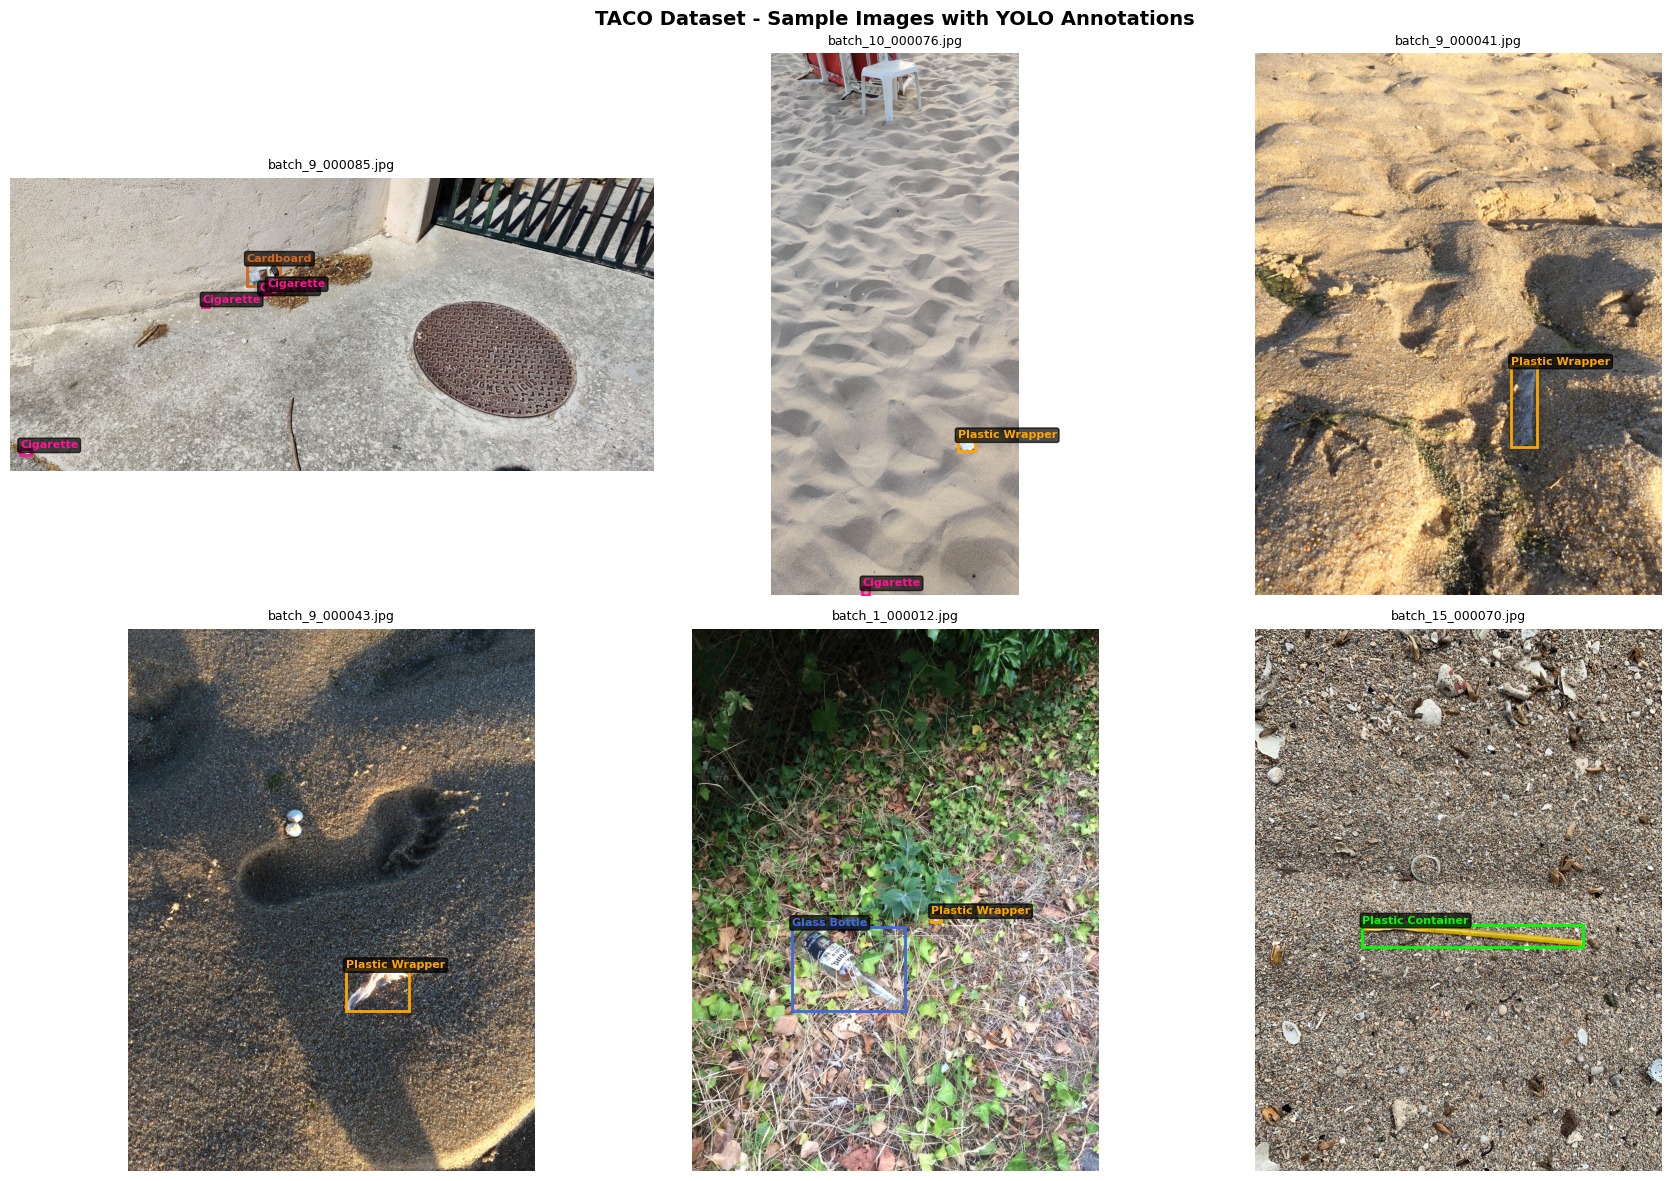

✅ Verification complete! Check the plot above.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random
import os

CLASS_NAMES = [
    "Plastic Bottle", "Plastic Bag", "Plastic Wrapper", "Plastic Container",
    "Styrofoam", "Crisp MLP Packet", "Glass Bottle", "Broken Glass",
    "Aluminium Can", "Food Can", "Metal Scrap", "Cardboard",
    "Paper", "Cigarette", "Hazardous"
]

COLORS = [
    '#00FFFF', '#FF6B6B', '#FFA500', '#00FF00', '#FF69B4',
    '#FFD700', '#4169E1', '#FF0000', '#C0C0C0', '#8B4513',
    '#808080', '#D2691E', '#FFFACD', '#FF1493', '#9400D3'
]

train_dir = "taco_yolo/images/train"
label_dir = "taco_yolo/labels/train"

images = [f for f in os.listdir(train_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
samples = random.sample(images, min(6, len(images)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, img_name in enumerate(samples):
    img = Image.open(os.path.join(train_dir, img_name))
    w, h = img.size
    axes[idx].imshow(img)
    axes[idx].set_title(img_name[:30], fontsize=9)
    axes[idx].axis('off')

    # Draw YOLO boxes
    label_file = os.path.join(label_dir, Path(img_name).stem + ".txt")
    if os.path.exists(label_file):
        with open(label_file) as f:
            for line in f:
                parts = line.strip().split()
                cls_id = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:])
                x1 = (xc - bw/2) * w
                y1 = (yc - bh/2) * h
                box_w = bw * w
                box_h = bh * h
                color = COLORS[cls_id % len(COLORS)]
                rect = patches.Rectangle((x1, y1), box_w, box_h,
                                         linewidth=2, edgecolor=color, facecolor='none')
                axes[idx].add_patch(rect)
                axes[idx].text(x1, y1-5, CLASS_NAMES[cls_id],
                              color=color, fontsize=8, fontweight='bold',
                              bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7))

plt.suptitle("TACO Dataset - Sample Images with YOLO Annotations", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("taco_samples.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Verification complete! Check the plot above.")


In [ ]:
from ultralytics import YOLO

# Load YOLOv11m with COCO pretrained weights (transfer learning)
model = YOLO("yolo11m.pt")

print("=" * 60)
print("  🚀 STARTING TRAINING: YOLOv11m on TACO (15 classes)")
print("  📊 Epochs: 100 | Image Size: 640 | Batch: 16")
print("  🎯 Fine-tuning from COCO pretrained weights")
print("=" * 60)

# Train
results = model.train(
    data="taco_yolo/taco.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    name="reloop_taco_v1",
    patience=20,           # Early stopping: stop if no improvement for 20 epochs
    save=True,
    save_period=25,         # Save checkpoint every 25 epochs
    plots=True,             # Generate training plots
    verbose=True,
    optimizer="AdamW",
    lr0=0.001,              # Initial learning rate
    lrf=0.01,               # Final learning rate factor
    warmup_epochs=5,        # Warmup for 5 epochs
    warmup_momentum=0.8,
    weight_decay=0.0005,
    mosaic=1.0,             # Mosaic augmentation (great for small datasets)
    mixup=0.15,             # MixUp augmentation
    copy_paste=0.1,         # Copy-paste augmentation
    hsv_h=0.015,            # HSV hue augmentation
    hsv_s=0.7,              # HSV saturation augmentation
    hsv_v=0.4,              # HSV value augmentation
    flipud=0.1,             # Vertical flip
    fliplr=0.5,             # Horizontal flip
    degrees=10.0,           # Rotation
    translate=0.2,          # Translation
    scale=0.5,              # Scale
    shear=2.0,              # Shear
)

print("\n✅ TRAINING COMPLETE!")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
  🚀 STARTING TRAINING: YOLOv11m on TACO (15 classes)
  📊 Epochs: 100 | Image Size: 640 | Batch: 16
  🎯 Fine-tuning from COCO pretrained weights
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=taco_yolo/taco.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4,

In [ ]:
from ultralytics import YOLO
import os

# Find the best weights
best_weights = "runs/detect/reloop_taco_v1/weights/best.pt"
if not os.path.exists(best_weights):
    # Search for it
    for root, dirs, files in os.walk("runs"):
        if "best.pt" in files:
            best_weights = os.path.join(root, "best.pt")
            break

print(f"📁 Best weights: {best_weights}")

# Load trained model
model = YOLO(best_weights)

# Validate on the validation set
metrics = model.val(data="taco_yolo/taco.yaml")

print("\n" + "=" * 60)
print("  📊 VALIDATION RESULTS")
print("=" * 60)
print(f"  mAP@50:    {metrics.box.map50:.4f}")
print(f"  mAP@50-95: {metrics.box.map:.4f}")
print(f"  Precision:  {metrics.box.mp:.4f}")
print(f"  Recall:     {metrics.box.mr:.4f}")
print("=" * 60)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
📁 Best weights: runs/detect/reloop_taco_v1/weights/best.pt


FileNotFoundError: [Errno 2] No such file or directory: 'runs/detect/reloop_taco_v1/weights/best.pt'